## Introduction

In this analysis, we model monthly Natural Gas prices using deterministic time-series components. The objective is to decompose the series into trend and seasonal structures and determine the most appropriate seasonal representation using out-of-sample validation. 

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11,4)

%config InlineBackend.figure_format = 'retina'

In [74]:
NatGas = pd.read_csv('Nat_Gas.csv', parse_dates= ['Dates']).set_index('Dates').to_period("M")
NatGas.head()

C:\Users\samid\AppData\Local\Temp\ipykernel_2416\712564060.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  NatGas = pd.read_csv('Nat_Gas.csv', parse_dates= ['Dates']).set_index('Dates').to_period("M")


,Prices
Dates,
2020-10,10.1
2020-11,10.3
2020-12,11.0
2021-01,10.9
2021-02,10.9


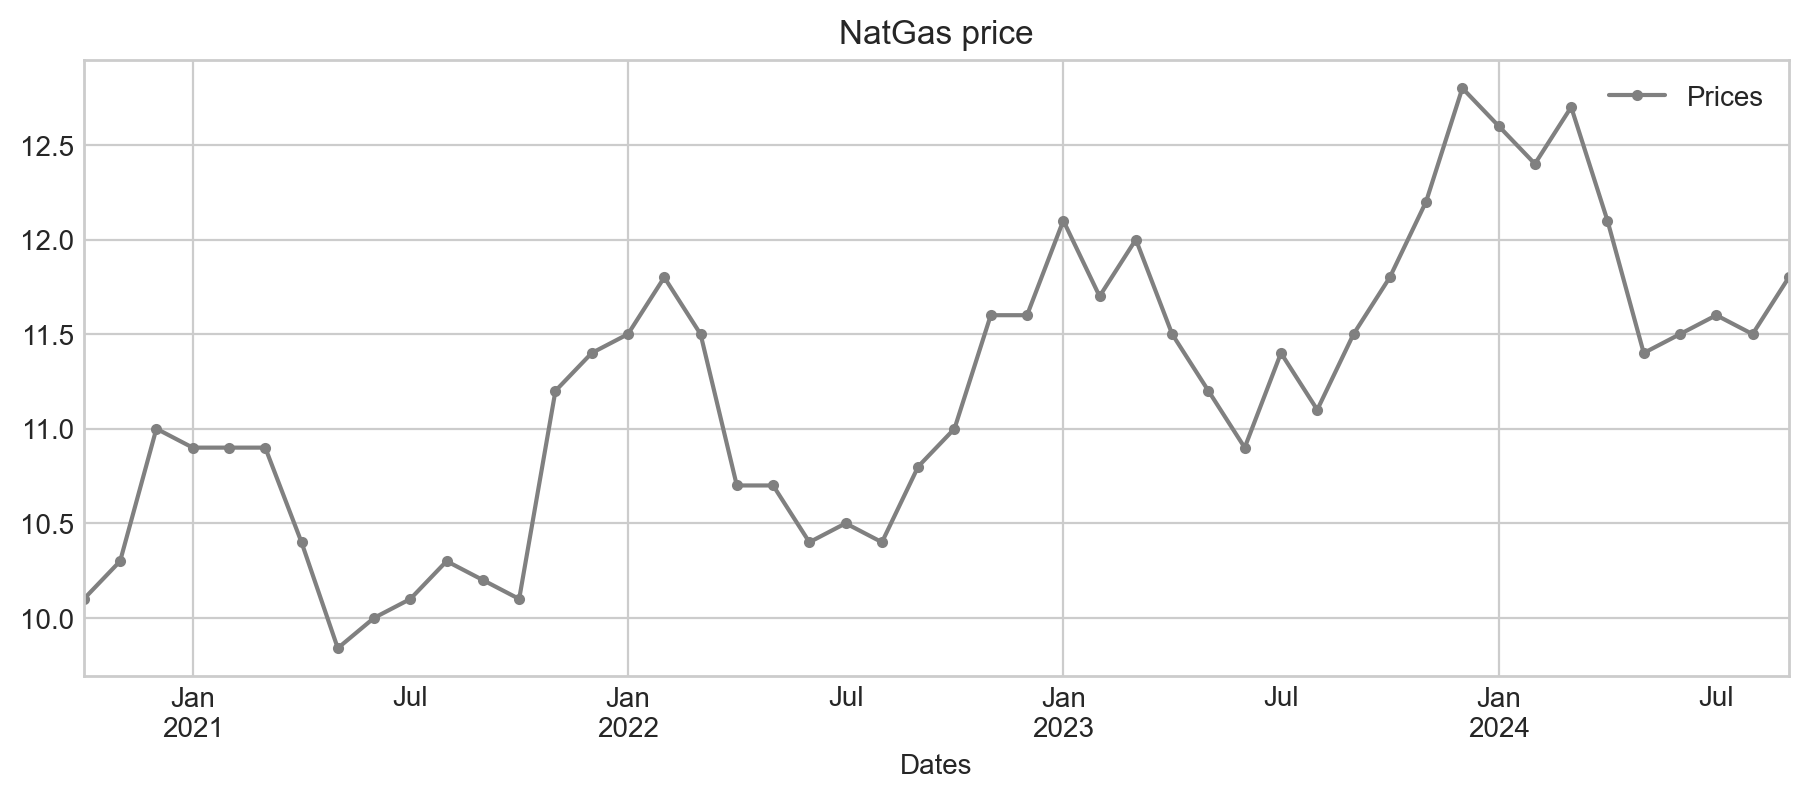

In [75]:
ax = NatGas.plot(style=".-", color="0.5", title="NatGas price")

This plot shows the raw monthly Natural Gas prices over time, revealing an upward trend with recurring annual fluctuations.

## Trend

We begin by modeling the long-term direction of the series using a linear deterministic trend component.

In [76]:
from statsmodels.tsa.deterministic import DeterministicProcess

dp = DeterministicProcess(index=NatGas.index, constant=True, order=1, drop=True)
X = dp.in_sample()
X.head()

,const,trend
Dates,,
2020-10,1.0,1.0
2020-11,1.0,2.0
2020-12,1.0,3.0
2021-01,1.0,4.0
2021-02,1.0,5.0


In [77]:
from sklearn.linear_model import LinearRegression

y = NatGas["Prices"]  

model = LinearRegression(fit_intercept=False)                
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

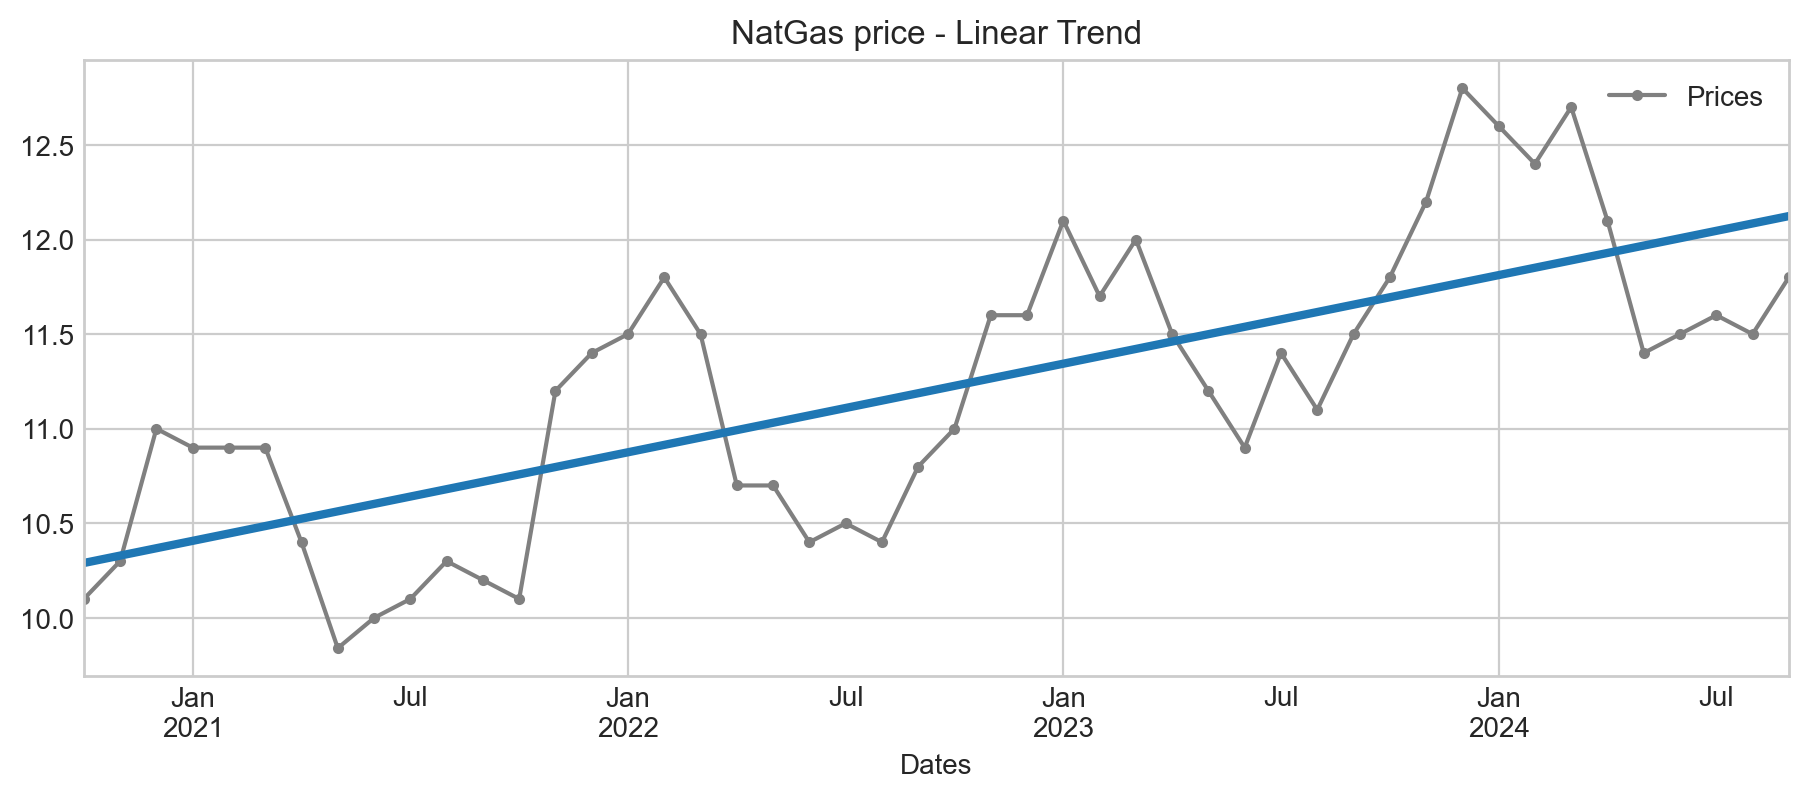

In [78]:
ax = NatGas.plot(style=".-", color="0.5", title="NatGas price - Linear Trend")
_= y_pred.plot(ax=ax, linewidth=3, label="Trend")

The linear regression line captures the overall upward movement in prices, isolating the long-term growth component from seasonal variation.

## Seasonality

Next, we investigate repeating yearly patterns in the data to determine whether a seasonal structure significantly improves model performance.

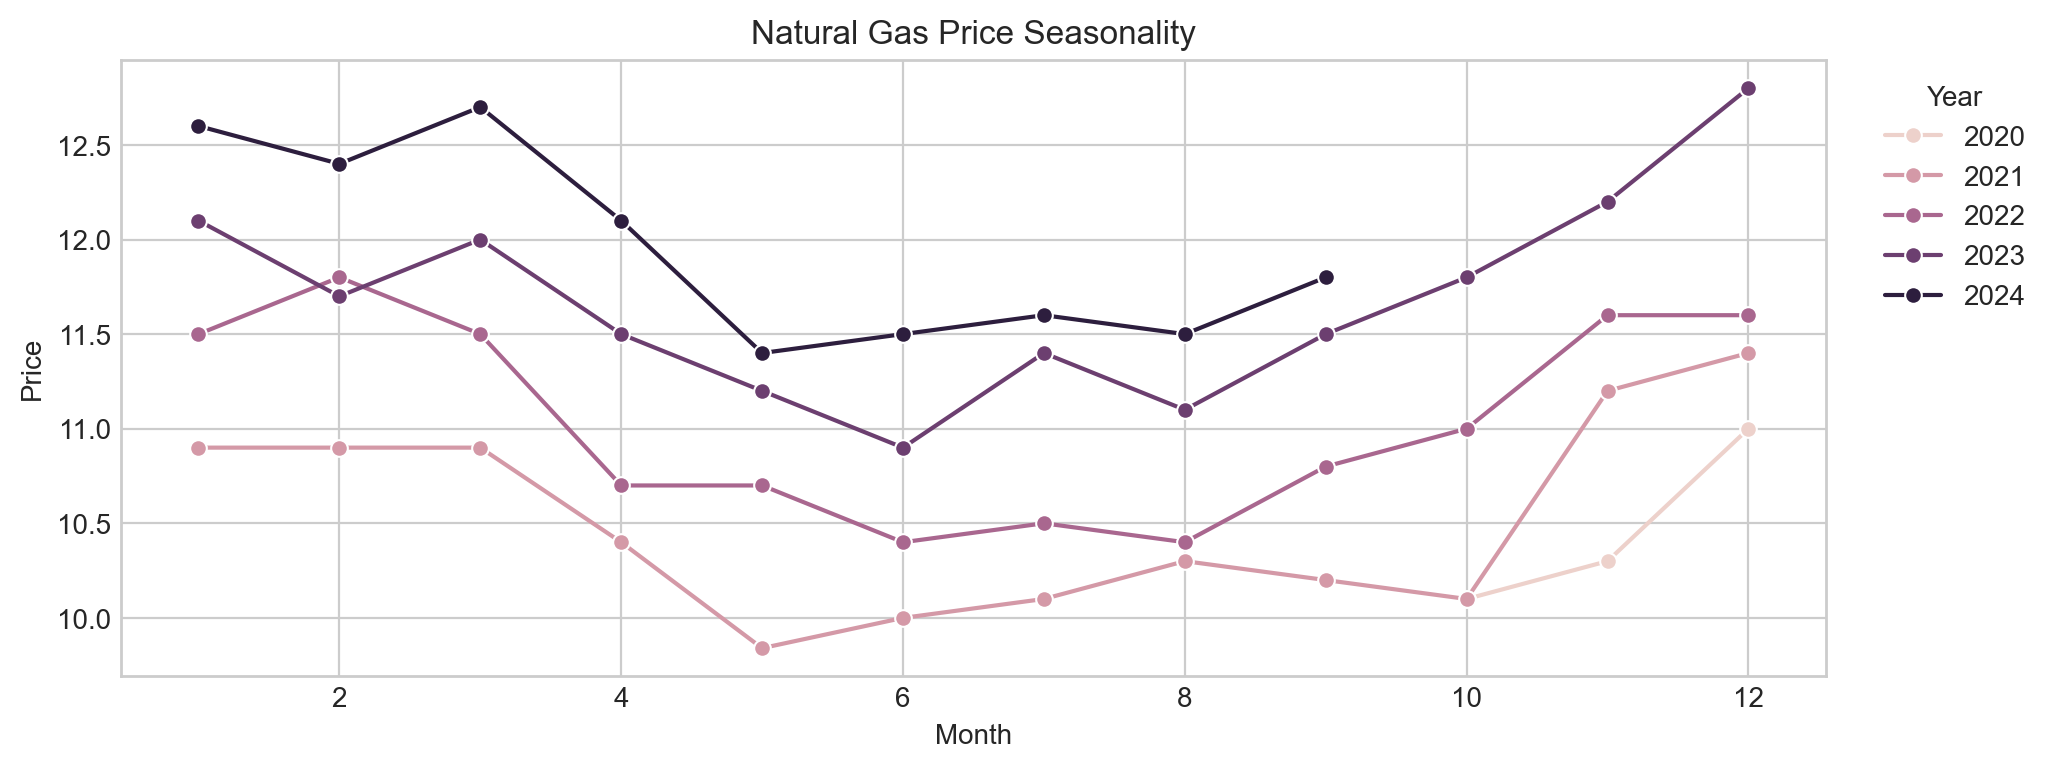

In [79]:
tmp = NatGas.copy()
tmp["month"] = tmp.index.month
tmp["year"] = tmp.index.year

sns.lineplot(data=tmp, x="month", y="Prices", hue="year", marker="o")
plt.title("Natural Gas Price Seasonality")
plt.xlabel("Month")
plt.ylabel("Price")
plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

This plot compares monthly price patterns across years, highlighting a consistent annual cycle with higher prices typically observed in winter months (January–March and November–December) and lower prices around late spring to early summer (May–July).

## Fourier Seasonal Modeling

To capture smooth annual cycles, we model seasonality using Fourier harmonics and evaluate different orders to balance bias and variance.

In [80]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

fourier = CalendarFourier(freq="A", order=1)   

dp = DeterministicProcess(
    index=NatGas.index,
    constant=True,              
    order=1,                    
    additional_terms=[fourier],  
    drop=True
)

X = dp.in_sample() 

c:\Users\samid\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [81]:
X.head()

,const,trend,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)"
Dates,,,,
2020-10,1.0,1.0,-0.999963,-0.008583
2020-11,1.0,2.0,-0.866025,0.500000
2020-12,1.0,3.0,-0.507415,0.861702
2021-01,1.0,4.0,0.000000,1.000000
2021-02,1.0,5.0,0.508671,0.860961


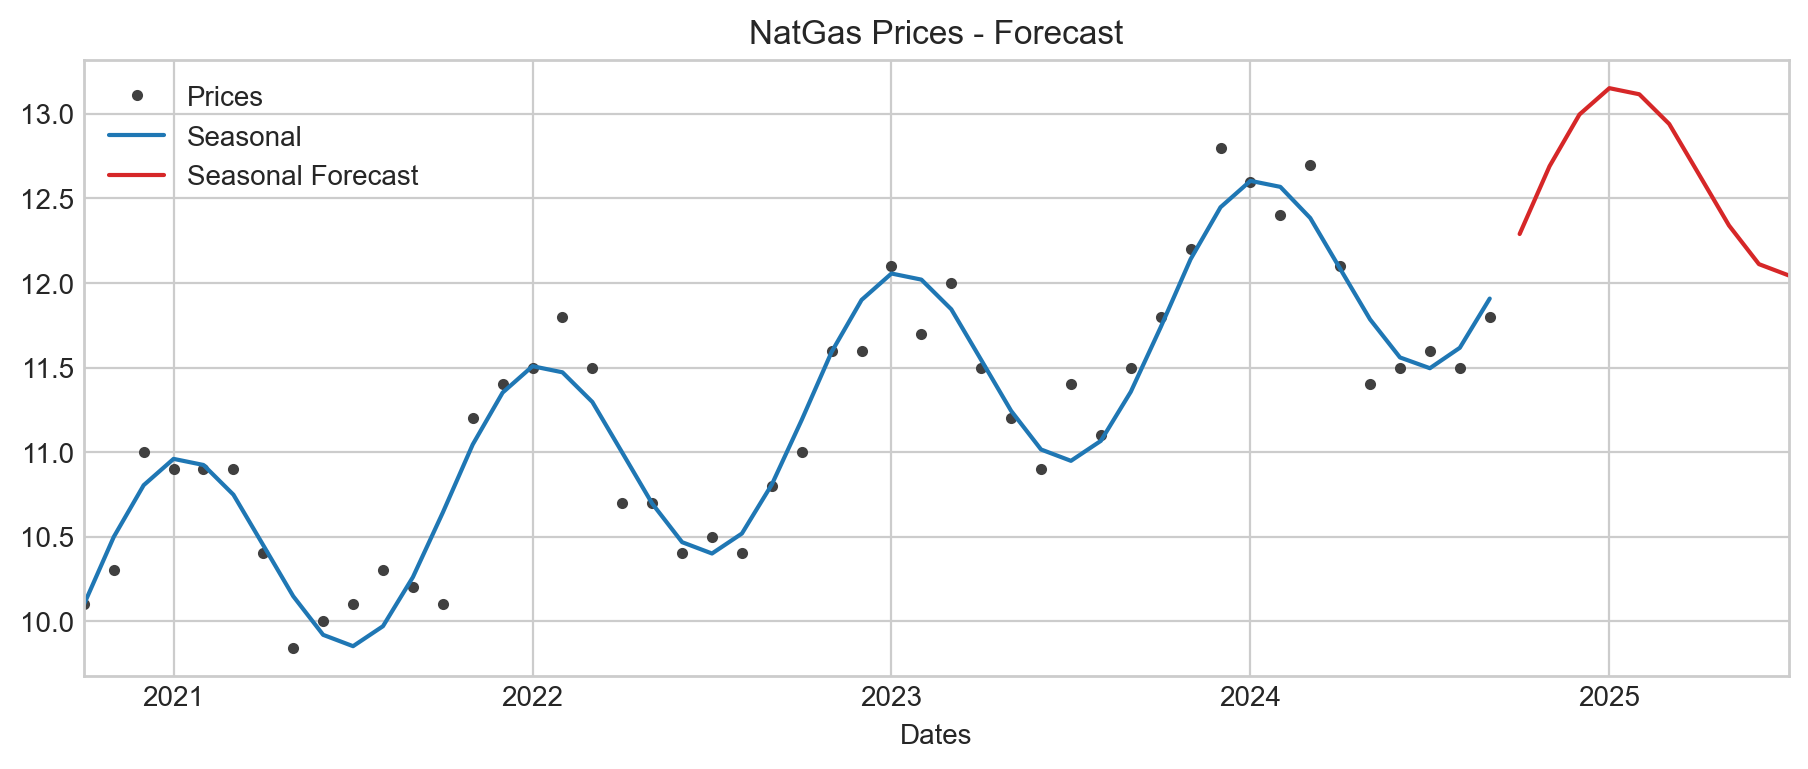

In [82]:
from sklearn.linear_model import LinearRegression
y = NatGas["Prices"]

model = LinearRegression(fit_intercept=False)
_ = model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=y.index)
X_fore = dp.out_of_sample(steps=10)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(color='0.25', style='.', title="NatGas Prices - Forecast")
ax = y_pred.plot(ax=ax, label="Seasonal")
ax = y_fore.plot(ax=ax, label="Seasonal Forecast", color='C3')
_ = ax.legend()

The Fourier-based seasonal model captures the smooth annual oscillation and extends the pattern forward to generate future monthly forecasts.

In [83]:
def estimate_price(date):
    date = pd.Timestamp(date)
    
    last_period = NatGas.index[-1]      
    target_period = date.to_period("M") 
    
    steps = (target_period - last_period).n
    
    if steps <= 0:
        return float(NatGas.loc[target_period])
    
    X_fore = dp.out_of_sample(steps=steps)
    y_fore = model.predict(X_fore)
    
    return float(y_fore[-1])

In [84]:
estimate_price("2027-01-31")

14.249071026132247

## Summary

The analysis shows that Natural Gas prices exhibit both a clear linear trend and a consistent annual seasonal pattern.

Seasonality was modeled using a Fourier representation, which captures smooth cyclical behavior more effectively than categorical seasonal indicators. A first-order harmonic was selected, as it adequately represents the dominant yearly cycle while maintaining model simplicity and stability.